# Prediccion de redshift desde el espacio latente del VAE (XGBoost)

Se extrae el vector latente `mu` (media de q(z|x)) de los VAE no supervisados
`vae2` y `vae3` (`file_out_data/checkpoints/vae_best2.pt`, `vae_best3.pt`,
entrenados con `scripts/VAE.py`) y se entrena un XGBoost para predecir el
redshift espectroscopico a partir de ese latente.

Estructura del notebook:
1. Setup del entorno (pensado para Google Colab; funciona igual en local)
2. Preprocesamiento de datos segun `scripts/preprocess_vae.py`
3. Carga de checkpoints y codificacion del latente (`mu`) para vae2 y vae3
4. Analisis completo del espacio latente: dimensiones activas, calidad de
   reconstruccion, proyeccion 2D (UMAP/PCA) y correlacion con features
   fotometricas/morfologicas de `data/features_images_20260707.csv`
5. Prediccion de redshift con XGBoost (dummy -> default -> Optuna -> PFI)
   evaluada en validacion y, al final, **una sola vez en test**
6. Foco en la tasa de errores catastroficos **eta**, definida en una funcion
   propia y evaluada en el conjunto de test para ambos modelos


## 1. Setup del entorno (Colab o local)

In [5]:
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# Rama de trabajo actual (con los checkpoints que uses en MODEL_RUNS mas
# abajo). Cambiar a "master" si ya hiciste merge.
REPO_BRANCH = "VAE-masking"


def _run(cmd):
    """subprocess en vez de `!cmd`: devuelve returncode y siempre imprime
    stdout/stderr, para poder diagnosticar un clone/fetch fallido (red,
    rate-limit de GitHub, etc.) en vez de un error generico de 'no encontrado'."""
    print(f"$ {' '.join(cmd)}")
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.stdout.strip():
        print(proc.stdout)
    if proc.stderr.strip():
        print(proc.stderr)
    return proc.returncode


if IN_COLAB:
    REPO_URL = "https://github.com/Tamaracarrasco/AS4501-Proyect.git"
    repo_root = Path("/content/AS4501-Proyect")

    # Importante: pararse en un directorio que seguro existe (y que no vamos a
    # borrar) ANTES de tocar repo_root. Si una corrida anterior dejo el kernel
    # con cwd == repo_root y despues lo borramos, cualquier subprocess (git
    # incluido) falla con "Unable to read current working directory".
    os.chdir("/content")

    def _repo_ready(path):
        # Chequeo generico (no atado a un checkpoint puntual: esos van
        # cambiando de una corrida a otra y esa era la fuente del bug).
        return (path / "scripts" / "VAE.py").exists()

    def _sync_branch(path, branch):
        """Actualiza un clone ya existente a la punta de `branch`, sin
        importar en que rama estaba antes. Evita el problema de re-usar un
        clone viejo (otra rama, o la misma rama pero desactualizada) que
        tenia menos checkpoints de los que ahora pide MODEL_RUNS."""
        if not (path / ".git").exists():
            return False
        if _run(["git", "-C", str(path), "fetch", "--depth", "1", "origin", branch]) != 0:
            return False
        # checkout -B fuerza la rama local `branch` a FETCH_HEAD, este ya
        # activo en esa rama o no: no depende de tracking branches previos.
        return _run(["git", "-C", str(path), "checkout", "-B", branch, "FETCH_HEAD"]) == 0

    if repo_root.exists() and not _sync_branch(repo_root, REPO_BRANCH):
        print(f"No se pudo sincronizar {repo_root} con la rama '{REPO_BRANCH}'; se re-clona.")
        _run(["rm", "-rf", str(repo_root)])

    if not repo_root.exists():
        rc = _run(["git", "clone", "--depth", "1", "--branch", REPO_BRANCH,
                    "--single-branch", REPO_URL, str(repo_root)])
        if rc != 0:
            raise RuntimeError(
                f"git clone termino con codigo {rc}; revisa el output de arriba "
                "(suele ser un problema de red o rate-limit de GitHub en Colab: "
                "reintenta la celda)."
            )

    if not _repo_ready(repo_root):
        raise FileNotFoundError(
            f"{repo_root} no tiene scripts/VAE.py tras clonar/sincronizar la rama "
            f"'{REPO_BRANCH}'. Revisa el output de arriba."
        )

    os.chdir(repo_root)

    # Dependencias extra que no vienen preinstaladas en Colab. No se instala
    # requirements.txt completo a proposito: fija torch==...+cpu y arrastraria
    # paquetes pesados innecesarios, pisando el torch+CUDA que Colab ya trae.
    !pip install -q xgboost optuna umap-learn astropy

    from google.colab import drive
    drive.mount("/content/drive")
else:
    repo_root = Path.cwd().resolve()
    for candidate in [repo_root, repo_root.parent, repo_root.parent.parent]:
        if (candidate / "scripts" / "VAE.py").exists():
            repo_root = candidate
            break
    else:
        raise FileNotFoundError(
            "No se encontro scripts/VAE.py desde el directorio actual."
        )

sys.path.insert(0, str(repo_root / "scripts"))
print(f"IN_COLAB   : {IN_COLAB}")
print(f"repo_root  : {repo_root}")

$ git -C /content/AS4501-Proyect fetch --depth 1 origin VAE-masking
From https://github.com/Tamaracarrasco/AS4501-Proyect
 * branch            VAE-masking -> FETCH_HEAD

$ git -C /content/AS4501-Proyect checkout -B VAE-masking FETCH_HEAD
Switched to a new branch 'VAE-masking'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB   : True
repo_root  : /content/AS4501-Proyect


## 2. Datos y preprocesamiento (`scripts/preprocess_vae.py`)

`data/features_images_20260707.csv` viaja en el repo (se trae solo con el
`git clone`). El tar de stamps (`cosmos_TC_202602.tar.gz.part_aa`, ~2 GB) es
demasiado pesado para git: hay que dejarlo en Google Drive y apuntar
`COSMOS_TAR_DRIVE_PATH` hacia el, o copiarlo a mano dentro de `data/`.

Si `file_out_data/vae_input.npz` ya existe (por ejemplo porque quedo del
entrenamiento de vae2/vae3) **se reutiliza tal cual**: `preprocess_vae.py` es
determinista (seed=42) y usando los mismos archivos de entrada reproduce
exactamente el mismo split train/val/test que vieron los checkpoints, asi
que no hace falta re-generarlo.


In [6]:
import os

# Editar solo si data/cosmos_TC_202602.tar.gz.part_aa no esta disponible
# localmente y hay que leerlo directo desde Drive (streaming, sin copiarlo).
COSMOS_TAR_DRIVE_PATH = "/content/drive/MyDrive/data_astroinf/cosmos_TC_202602.tar.gz.part_aa"

npz_path = repo_root / "file_out_data" / "vae_input.npz"
local_tar = repo_root / "data" / "cosmos_TC_202602.tar.gz.part_aa"

if not npz_path.exists() and not local_tar.exists() and IN_COLAB and Path(COSMOS_TAR_DRIVE_PATH).exists():
    os.environ["COSMOS_TAR"] = COSMOS_TAR_DRIVE_PATH
    print(f"COSMOS_TAR -> {COSMOS_TAR_DRIVE_PATH}")


In [7]:
from preprocess_vae import main as preprocess_main

tar_path = Path(os.environ.get("COSMOS_TAR", local_tar))
features_path = repo_root / "data" / "features_images_20260707.csv"

if npz_path.exists():
    print(f"Ya existe {npz_path}, se omite el preprocesamiento.")
else:
    if not tar_path.exists():
        raise FileNotFoundError(
            f"No se encontro el tar de stamps en {tar_path}.\n"
            "Monta Drive y define COSMOS_TAR_DRIVE_PATH (celda anterior) o "
            "copia el tar a data/ antes de correr esta celda."
        )
    if not features_path.exists():
        raise FileNotFoundError(f"No se encontro el CSV de features: {features_path}")
    preprocess_main(tar_path=str(tar_path), features_path=str(features_path))


Ya existe /content/AS4501-Proyect/file_out_data/vae_input.npz, se omite el preprocesamiento.


## 3. Carga de utilidades del VAE, datos y checkpoints (vae2, vae3 y vae7)

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from VAE import MultiResVAE, GPUBatches, set_seed, validate

plt.style.use("default")
pd.set_option("display.max_columns", 50)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

ckpt_dir = repo_root / "file_out_data" / "checkpoints"
MODEL_RUNS = {
    "vae2": ckpt_dir / "vae_best2.pt",
    "vae3": ckpt_dir / "vae_best3.pt",
    "vae7": ckpt_dir / "vae_best7.pt",
}
for name, p in MODEL_RUNS.items():
    if not p.exists():
        raise FileNotFoundError(f"No se encontro el checkpoint {name}: {p}")


device: cuda


In [10]:
npz = np.load(npz_path, allow_pickle=True)
X_all = npz["X"]                                   # (N, 5, 4, 30, 30)
ids_all = np.array([str(i) for i in npz["ids"]])
type_all = np.asarray(npz["type"]).astype(str)
z_all = np.asarray(npz["z"], dtype=np.float32)
idx_train = np.asarray(npz["idx_train"])
idx_val = np.asarray(npz["idx_val"])
idx_test = np.asarray(npz["idx_test"])

split_all = np.array(["train"] * len(ids_all))
split_all[idx_val] = "val"
split_all[idx_test] = "test"

print(f"N total = {len(ids_all)}  |  train = {len(idx_train)}  "
      f"val = {len(idx_val)}  test = {len(idx_test)}")


N total = 21285  |  train = 17028  val = 2128  test = 2129


In [11]:
@torch.no_grad()
def load_vae(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device)
    config = dict(ckpt["config"])
    model = MultiResVAE(config).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, config


@torch.no_grad()
def encode_all(model, X, device, batch_size=256):
    """Codifica todo X -> (mu, logvar) del encoder del VAE, en batches."""
    mus, logvars = [], []
    for i in range(0, len(X), batch_size):
        xb = torch.as_tensor(X[i:i + batch_size], dtype=torch.float32).to(device)
        mu, logvar = model.encode(xb)
        mus.append(mu.cpu().numpy())
        logvars.append(logvar.cpu().numpy())
    return np.concatenate(mus, axis=0), np.concatenate(logvars, axis=0)


latents = {}
for name, ckpt_path in MODEL_RUNS.items():
    model, config = load_vae(ckpt_path, device)
    mu, logvar = encode_all(model, X_all, device)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"{name}: {n_par/1e6:.2f}M params | z_dim={config['z_dim']} | mu.shape={mu.shape}")
    latents[name] = {"model": model, "config": config, "mu": mu, "logvar": logvar}


vae2: 3.65M params | z_dim=64 | mu.shape=(21285, 64)
vae3: 3.65M params | z_dim=64 | mu.shape=(21285, 64)
vae7: 3.65M params | z_dim=64 | mu.shape=(21285, 64)


## 4. Analisis del espacio latente

### 4.1 Calidad de reconstruccion en test (contexto)

Antes de usar el latente como input de un regresor conviene saber que tan bien
lo esta describiendo el VAE: si la reconstruccion es mala, el latente puede
no estar capturando la estructura de la imagen.

In [12]:
def test_recon_quality(model, config, X_test, device):
    Xte = torch.as_tensor(X_test, dtype=torch.float32)
    loader = GPUBatches(Xte, config["batch_size"], device, shuffle=False)
    return validate(model, loader, device, config, image_metrics=True)


recon_rows = []
for name, d in latents.items():
    m = test_recon_quality(d["model"], d["config"], X_all[idx_test], device)
    recon_rows.append({
        "model": name, "recon": m["recon"], "kl": m["kl"], "mse_px": m["mse_px"],
        "ssim": m.get("ssim", float("nan")), "psnr": m.get("psnr", float("nan")),
        "active_dims": m["active_dims"], "z_dim": d["config"]["z_dim"],
    })
pd.DataFrame(recon_rows).set_index("model")


,recon,kl,mse_px,ssim,psnr,active_dims,z_dim
model,,,,,,,
vae2,6.197568,12.740180,0.000344,NaN,NaN,64,64
vae3,5.391003,20.873407,0.000300,NaN,NaN,64,64
vae7,5.443583,6.247726,0.000302,NaN,NaN,64,64


### 4.2 Dimensiones activas del latente (KL por dimension)

Una dimension se considera "activa" si su KL promedio respecto al prior
supera un umbral (0.01): dimensiones inactivas colapsaron a N(0,1) y no
aportan informacion util para el regresor.

vae2: 64/64 dimensiones activas (KL/dim > 0.01)
vae3: 64/64 dimensiones activas (KL/dim > 0.01)
vae7: 64/64 dimensiones activas (KL/dim > 0.01)


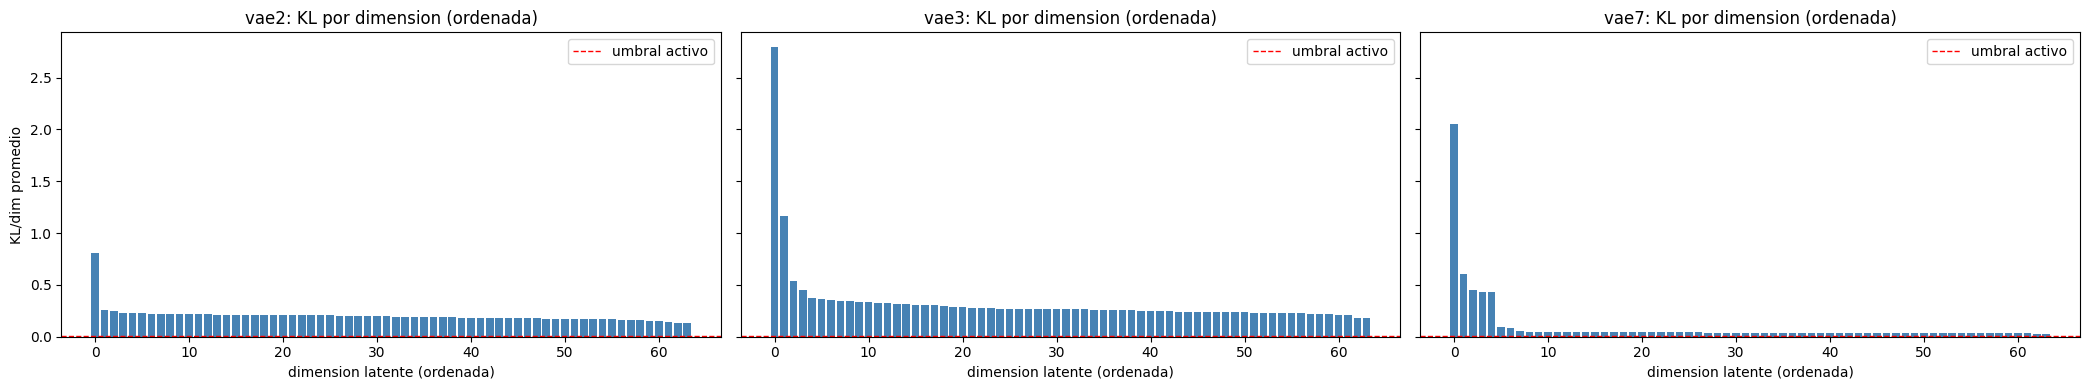

In [13]:
def active_dims_report(mu, logvar, thresh=0.01):
    kld = (-0.5 * (1 + logvar - mu ** 2 - np.exp(logvar))).mean(axis=0)
    return kld, kld > thresh


for name, d in latents.items():
    kld, active = active_dims_report(d["mu"], d["logvar"])
    d["kld"], d["active"] = kld, active
    print(f"{name}: {active.sum()}/{len(active)} dimensiones activas (KL/dim > 0.01)")

fig, axes = plt.subplots(1, len(latents), figsize=(7 * len(latents), 4), sharey=True)
for ax, (name, d) in zip(np.atleast_1d(axes), latents.items()):
    order = np.argsort(-d["kld"])
    colors = ["steelblue" if a else "lightgray" for a in d["active"][order]]
    ax.bar(range(len(d["kld"])), d["kld"][order], color=colors)
    ax.axhline(0.01, color="red", ls="--", lw=1, label="umbral activo")
    ax.set_title(f"{name}: KL por dimension (ordenada)")
    ax.set_xlabel("dimension latente (ordenada)")
    ax.legend()
axes_ = np.atleast_1d(axes)
axes_[0].set_ylabel("KL/dim promedio")
plt.tight_layout()
plt.show()


### 4.3 Proyeccion 2D del latente (UMAP o PCA)

Coloreada por tipo morfologico, redshift y split, para ver si el latente
separaescoge estructura relevante para el problema.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


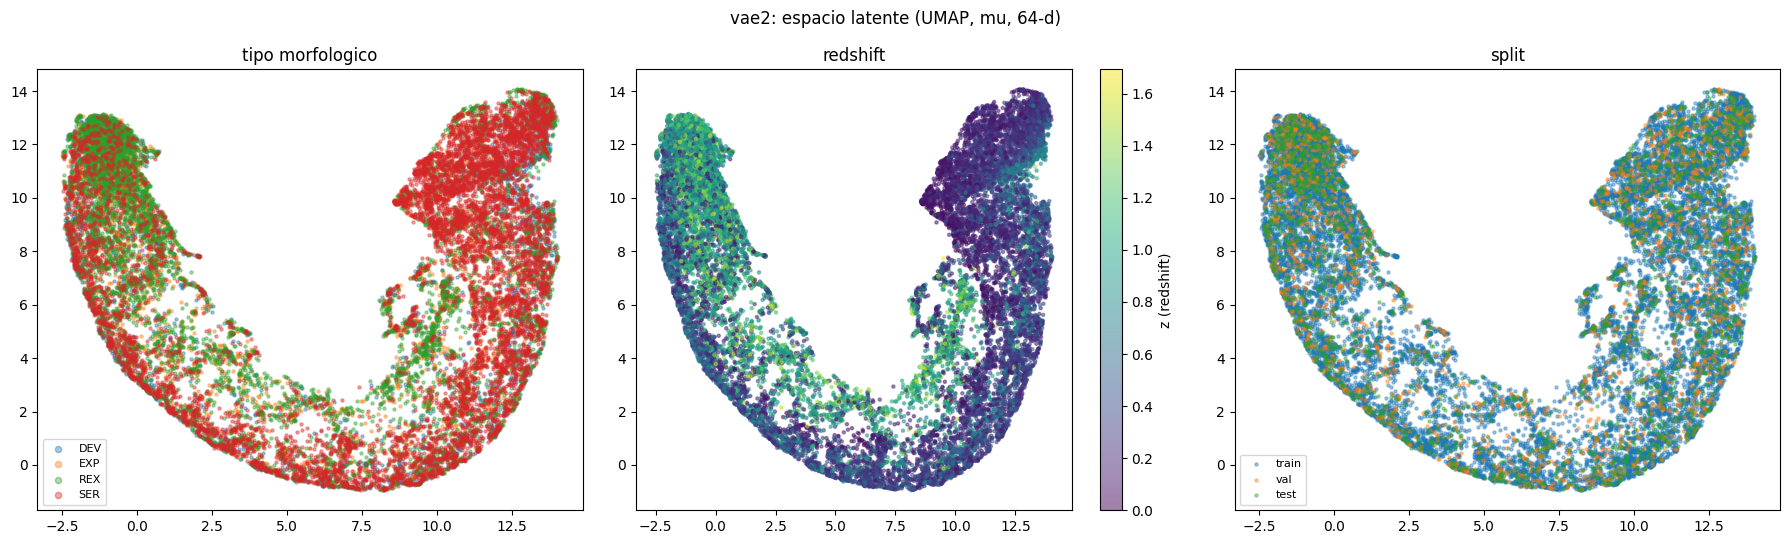

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


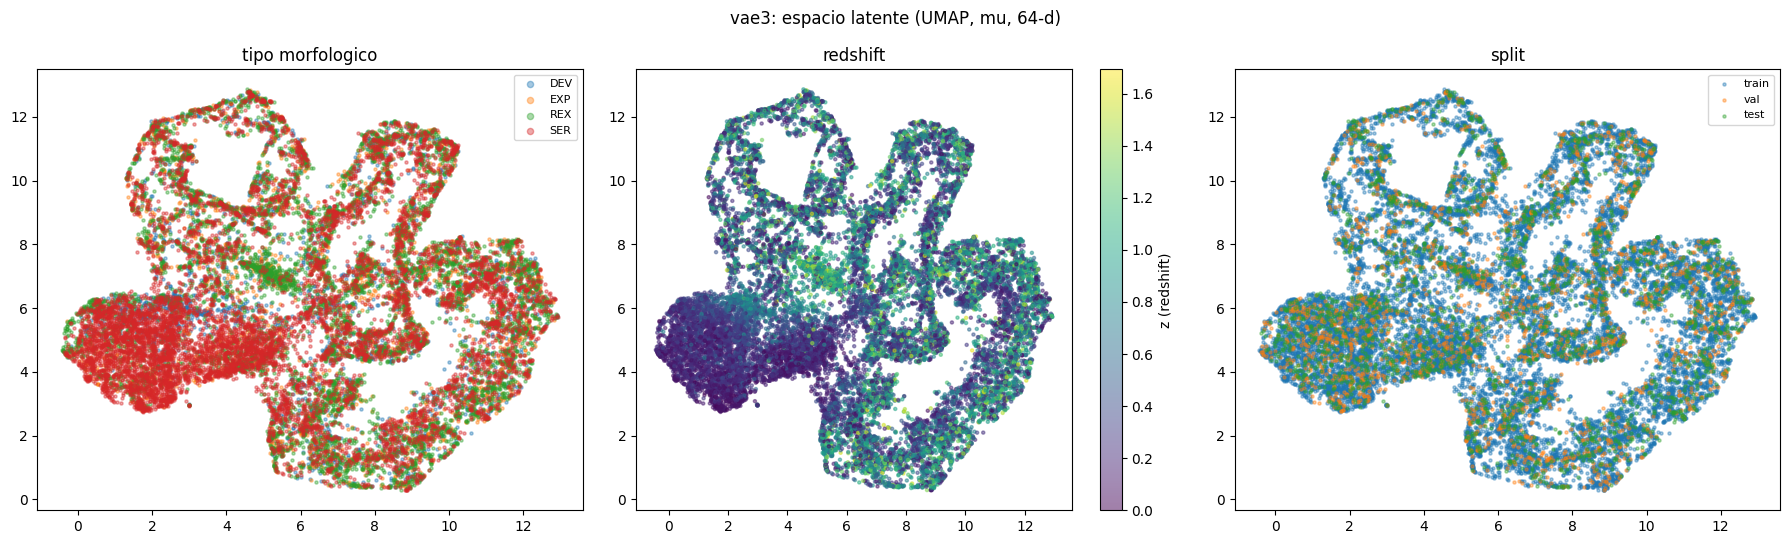

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


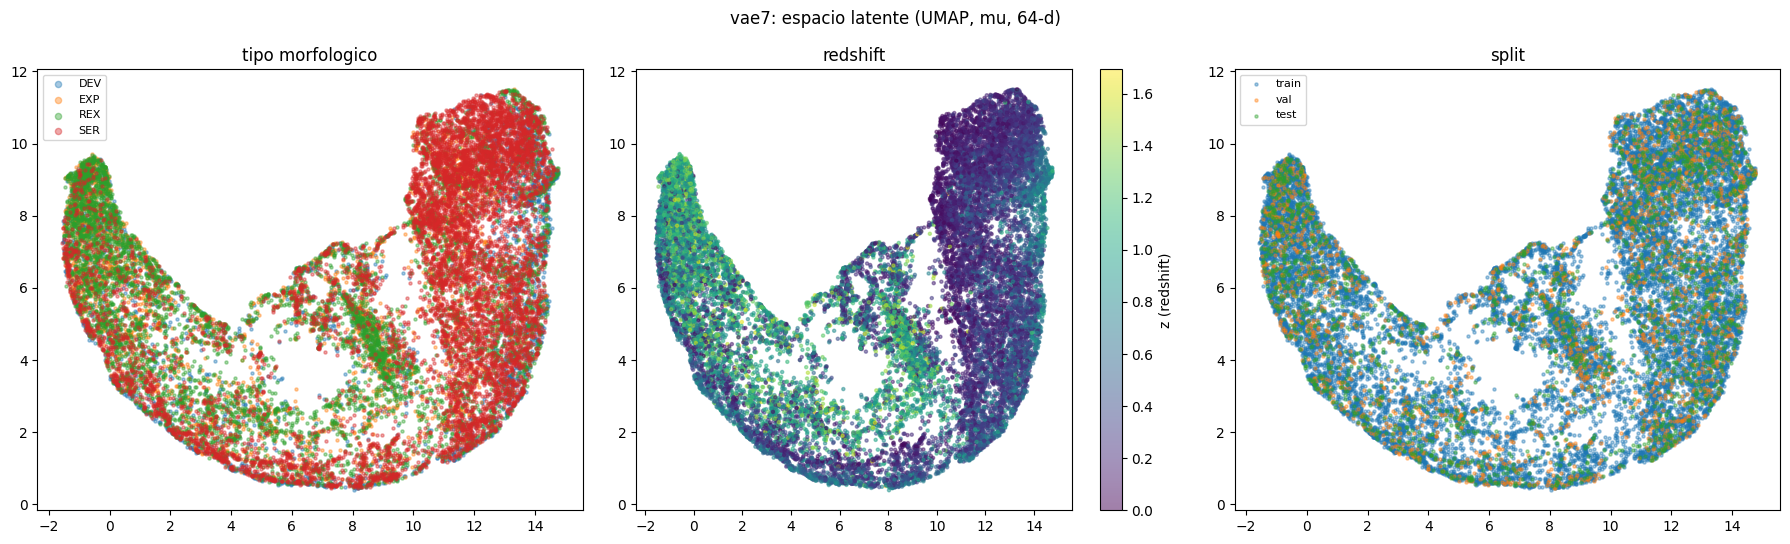

In [14]:
try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False
    from sklearn.decomposition import PCA


def project_2d(mu, seed=42):
    if HAS_UMAP:
        return umap.UMAP(n_components=2, random_state=seed).fit_transform(mu), "UMAP"
    from sklearn.decomposition import PCA
    return PCA(n_components=2).fit_transform(mu), "PCA (umap no instalado)"


for name, d in latents.items():
    emb, method = project_2d(d["mu"])
    d["emb2d"] = emb

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for t in np.unique(type_all):
        m = type_all == t
        axes[0].scatter(emb[m, 0], emb[m, 1], s=5, alpha=0.4, label=t)
    axes[0].legend(markerscale=2, fontsize=8)
    axes[0].set_title("tipo morfologico")

    sc = axes[1].scatter(emb[:, 0], emb[:, 1], s=5, alpha=0.5, c=z_all, cmap="viridis")
    plt.colorbar(sc, ax=axes[1], label="z (redshift)")
    axes[1].set_title("redshift")

    for s, c in zip(["train", "val", "test"], ["tab:blue", "tab:orange", "tab:green"]):
        m = split_all == s
        axes[2].scatter(emb[m, 0], emb[m, 1], s=5, alpha=0.4, label=s, color=c)
    axes[2].legend(fontsize=8)
    axes[2].set_title("split")

    fig.suptitle(f"{name}: espacio latente ({method}, mu, {d['mu'].shape[1]}-d)")
    plt.tight_layout()
    plt.show()


### 4.4 Correlacion del latente con features fotometricas/morfologicas

Se reutiliza la ingenieria de features de `Regression_XGBoost.ipynb`
(magnitudes corregidas por extincion y colores) sobre
`data/features_images_20260707.csv`, unida por `desi_id` a cada dimension
latente.

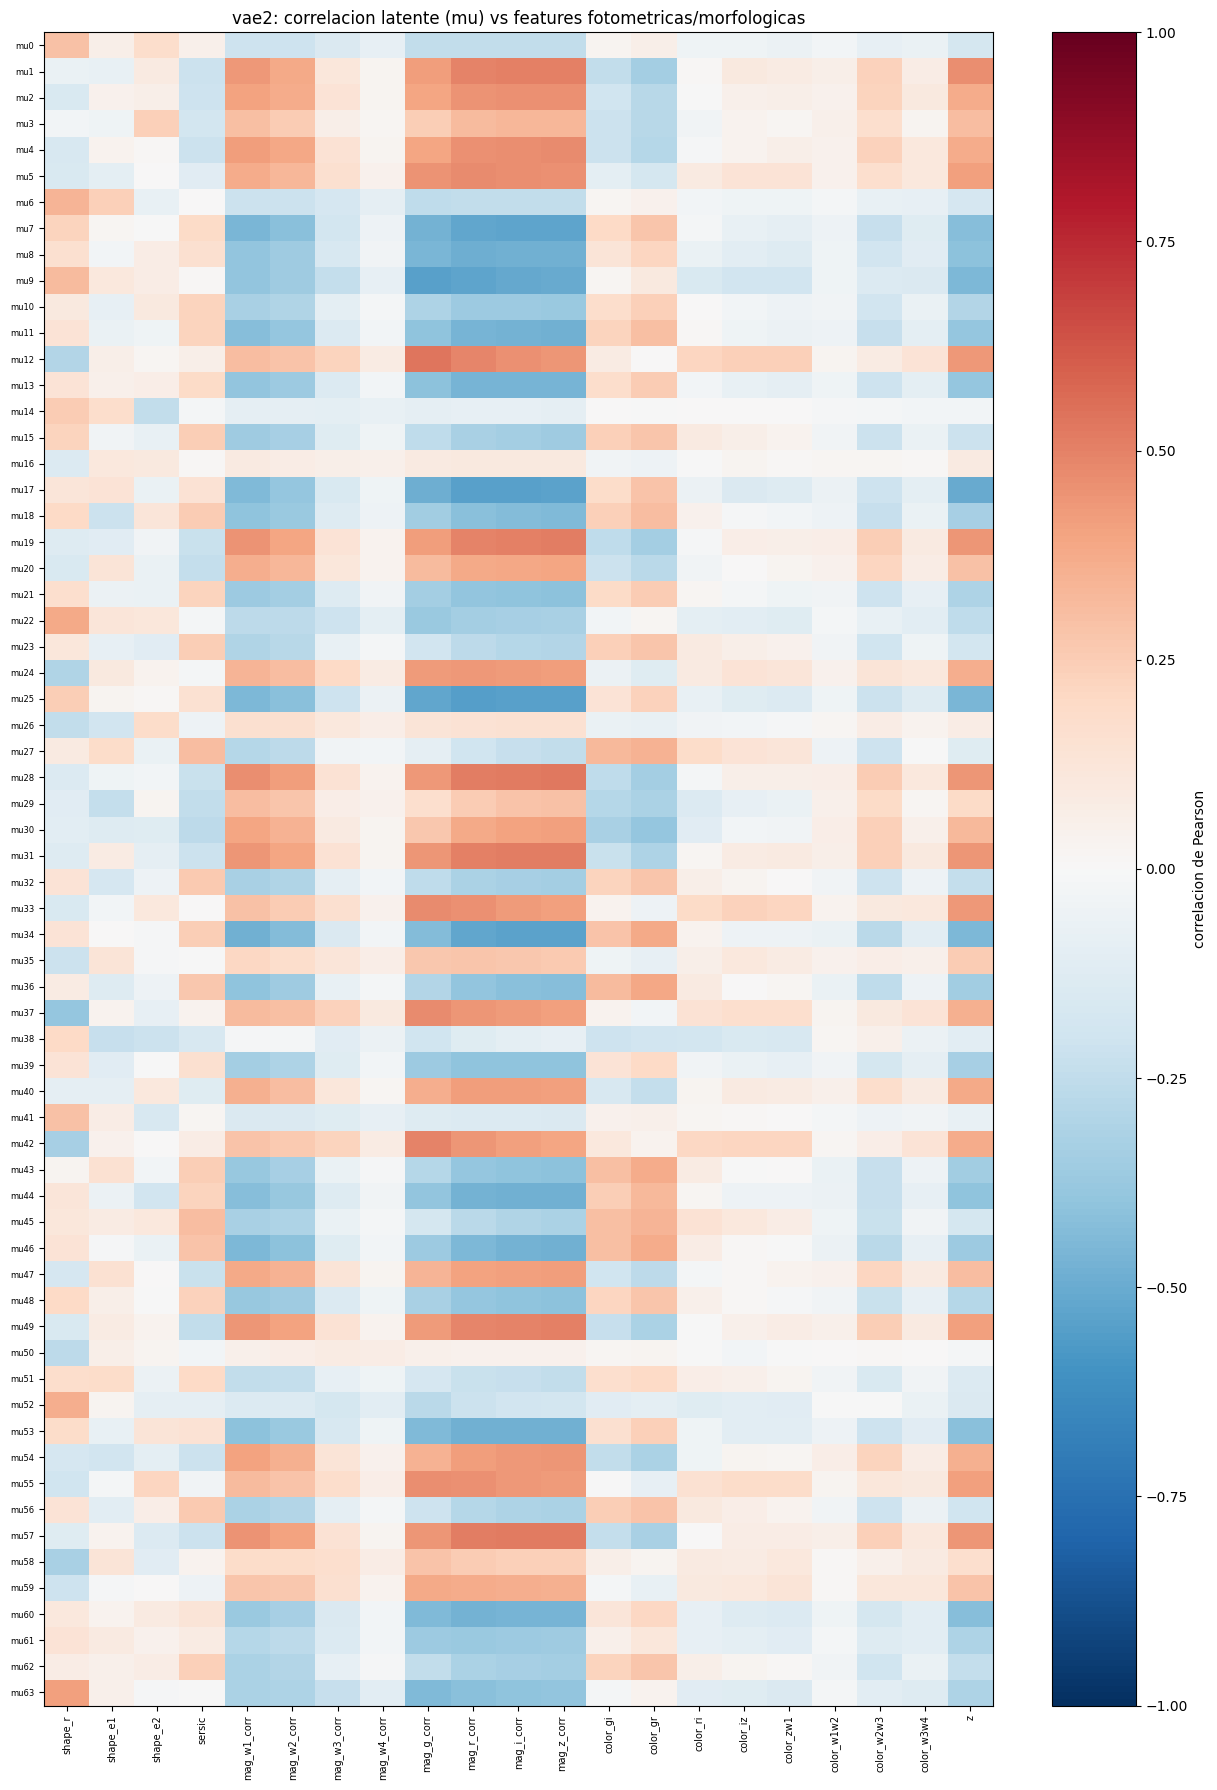

vae2: dimensiones latentes mas correlacionadas con z (top 15):
mu17    0.507237
mu1     0.466072
mu25    0.458200
mu34    0.452150
mu9     0.451898
mu57    0.444212
mu31    0.442333
mu28    0.440640
mu19    0.438436
mu33    0.432565
mu12    0.429705
mu60    0.426513
mu7     0.426496
mu53    0.415853
mu8     0.413101
Name: z, dtype: float64


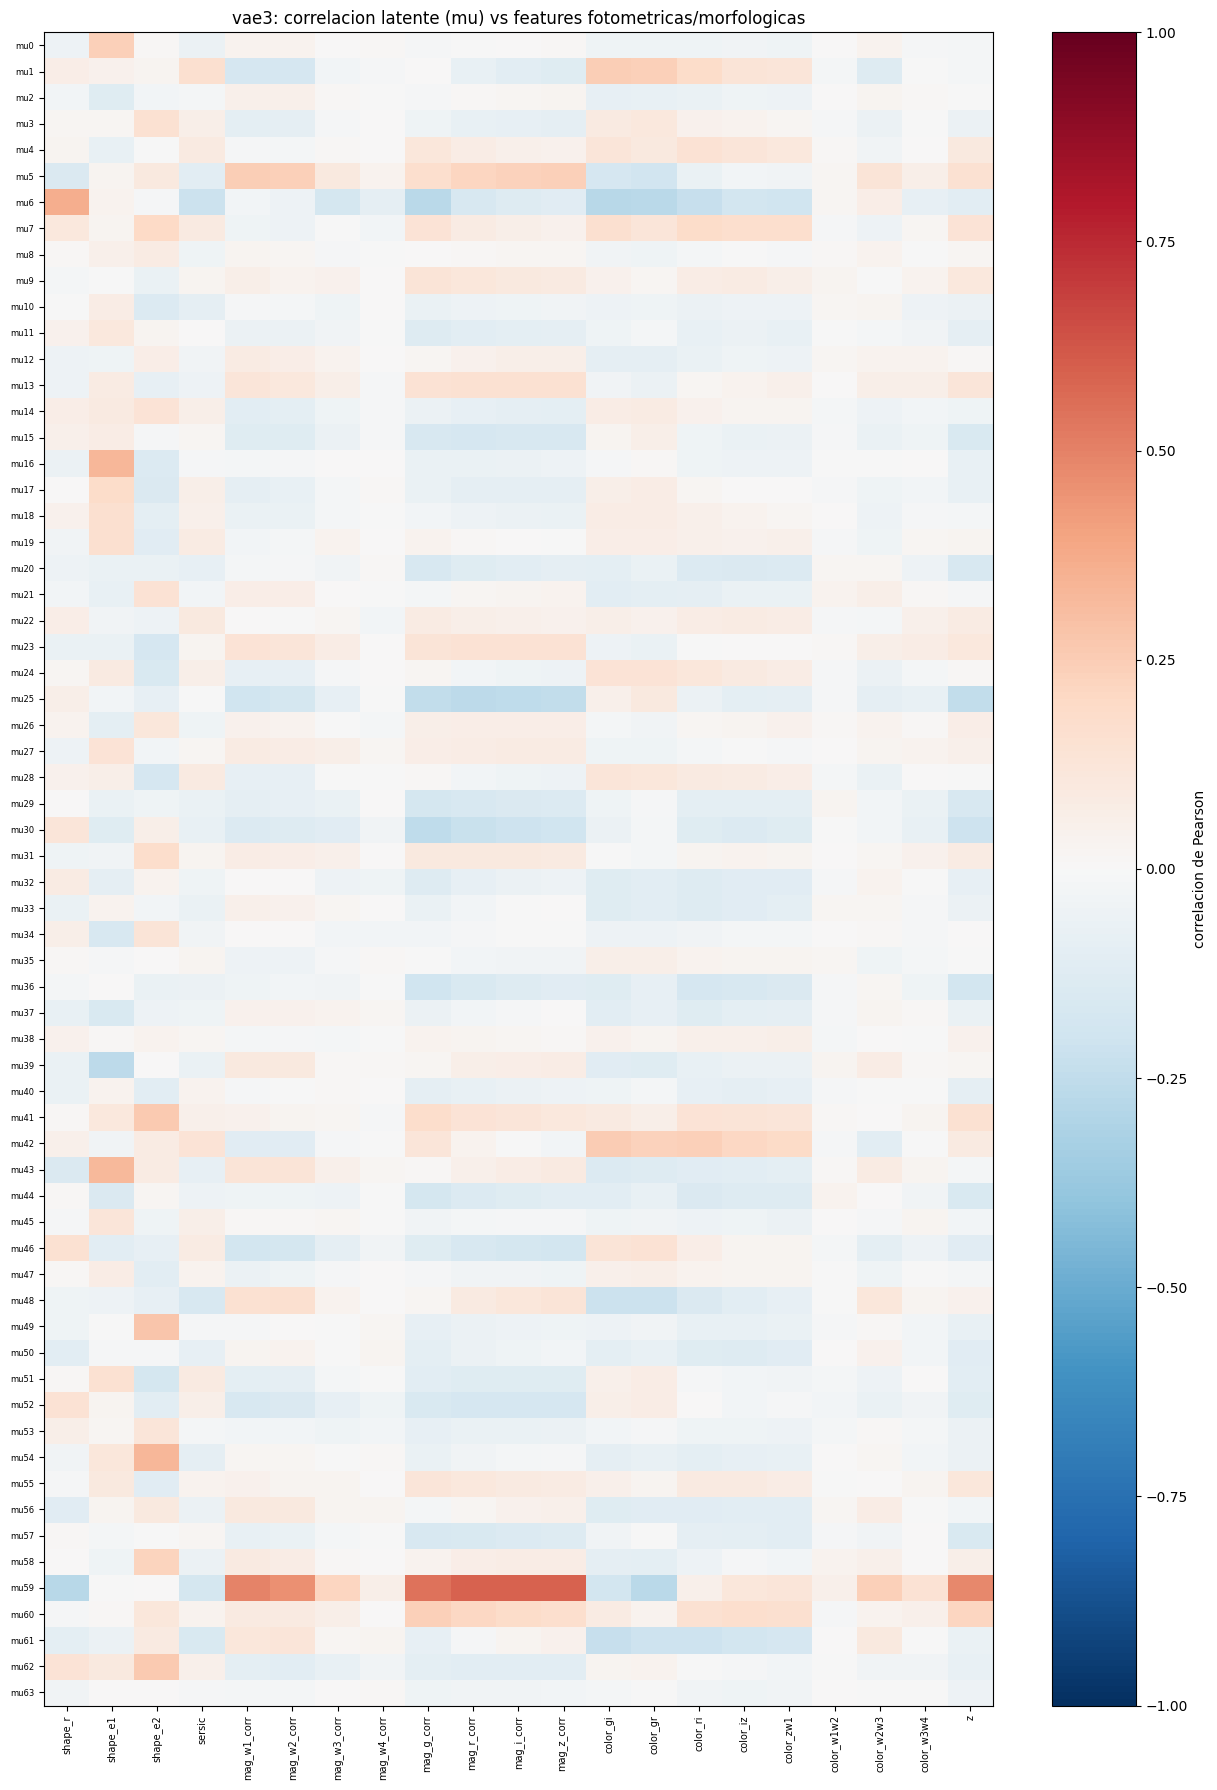

vae3: dimensiones latentes mas correlacionadas con z (top 15):
mu59    0.480880
mu25    0.243091
mu60    0.216523
mu30    0.204018
mu36    0.179808
mu20    0.158405
mu29    0.157615
mu41    0.156008
mu57    0.154640
mu5     0.154303
mu44    0.148838
mu15    0.148545
mu7     0.138738
mu13    0.122658
mu52    0.120673
Name: z, dtype: float64


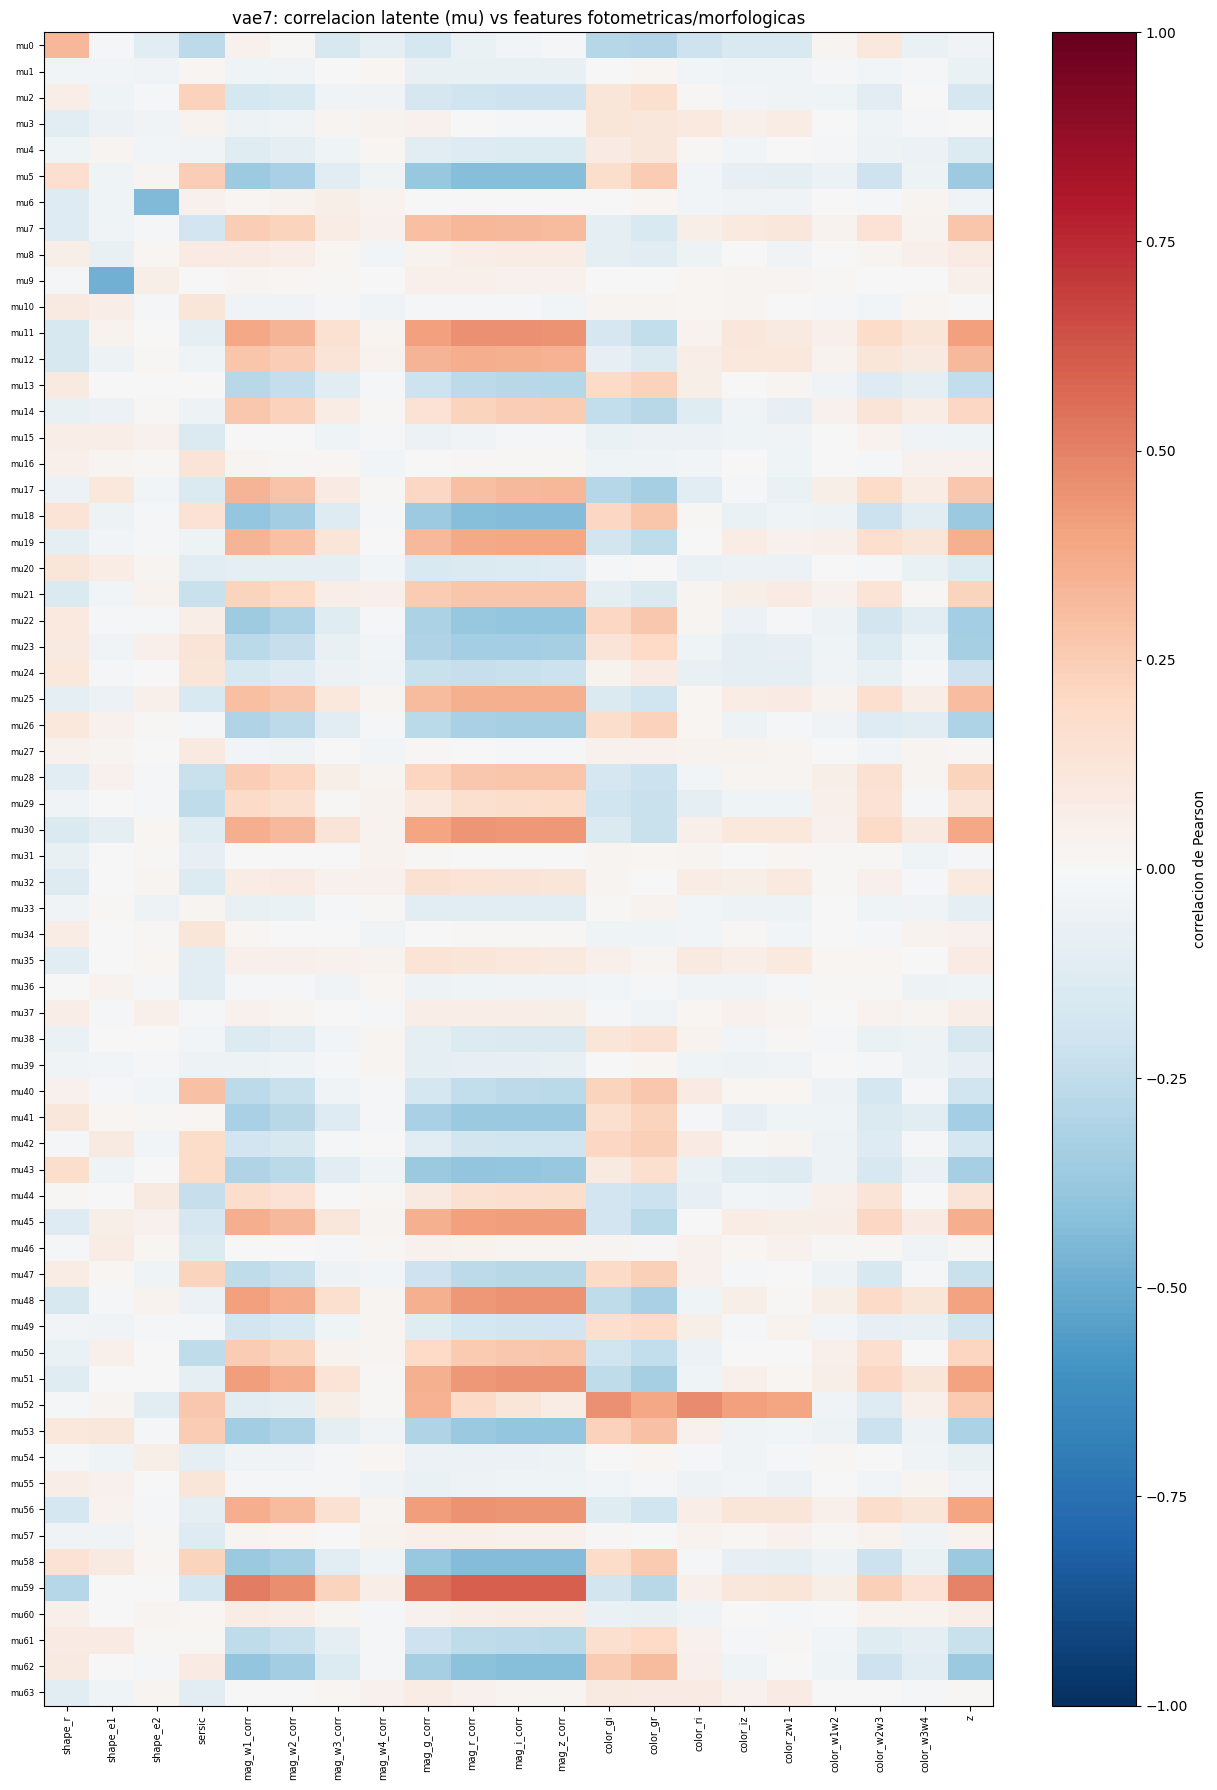

vae7: dimensiones latentes mas correlacionadas con z (top 15):
mu59    0.495144
mu11    0.413666
mu51    0.402159
mu48    0.399518
mu56    0.393548
mu30    0.389987
mu62    0.374718
mu58    0.370289
mu18    0.368786
mu45    0.362568
mu5     0.362472
mu19    0.358030
mu41    0.343361
mu22    0.341804
mu43    0.333771
Name: z, dtype: float64


In [15]:
from preprocess_vae import BANDS as OPTICAL_BANDS

feat_raw = pd.read_csv(repo_root / "data" / "features_images_20260707.csv")
feat_raw["desi_id"] = feat_raw["desi_id"].astype(str)


def engineer_features(df):
    """Magnitudes corregidas por extincion (WISE + opticas) y colores."""
    df = df.copy()
    for b in ["w1", "w2", "w3", "w4"]:
        flux_corr = df[f"flux_{b}"] / df[f"mw_transmission_{b}"]
        df[f"mag_{b}_corr"] = 22.5 - 2.5 * np.log10(flux_corr.where(flux_corr > 0))
    for b in OPTICAL_BANDS:
        flux_corr = df[f"flux_{b}"] / df[f"mw_transmission_{b}"]
        df[f"mag_{b}_corr"] = 22.5 - 2.5 * np.log10(flux_corr.where(flux_corr > 0))

    color_pairs = [("g", "i"), ("g", "r"), ("r", "i"), ("i", "z"),
                    ("z", "w1"), ("w1", "w2"), ("w2", "w3"), ("w3", "w4")]
    for b1, b2 in color_pairs:
        df[f"color_{b1}{b2}"] = df[f"mag_{b1}_corr"] - df[f"mag_{b2}_corr"]

    keep = ["desi_id", "type", "shape_r", "shape_e1", "shape_e2", "sersic"] + \
           [c for c in df.columns if c.startswith("mag_") or c.startswith("color_")]
    return df[keep]


feat_eng = engineer_features(feat_raw)
meta_df = pd.DataFrame({"desi_id": ids_all, "type": type_all, "z": z_all, "split": split_all})


def latent_feature_correlation(mu, meta_df, feat_eng, name, top_k=15):
    mu_cols = [f"mu{i}" for i in range(mu.shape[1])]
    mu_df = pd.DataFrame(mu, columns=mu_cols)
    mu_df["desi_id"] = meta_df["desi_id"].to_numpy()
    merged = mu_df.merge(feat_eng, on="desi_id", how="left")
    merged["z"] = meta_df["z"].to_numpy()

    num_feats = [c for c in feat_eng.columns if c not in ("desi_id", "type")] + ["z"]
    corr = merged[mu_cols + num_feats].corr().loc[mu_cols, num_feats]

    plt.figure(figsize=(0.5 * len(num_feats) + 2, 0.25 * len(mu_cols) + 2))
    plt.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    plt.colorbar(label="correlacion de Pearson")
    plt.xticks(range(len(num_feats)), num_feats, rotation=90, fontsize=7)
    plt.yticks(range(len(mu_cols)), mu_cols, fontsize=6)
    plt.title(f"{name}: correlacion latente (mu) vs features fotometricas/morfologicas")
    plt.tight_layout()
    plt.show()

    z_corr = corr["z"].abs().sort_values(ascending=False)
    print(f"{name}: dimensiones latentes mas correlacionadas con z (top {top_k}):")
    print(z_corr.head(top_k))
    return corr, merged


for name, d in latents.items():
    corr, merged = latent_feature_correlation(d["mu"], meta_df, feat_eng, name)
    d["feat_corr"], d["merged"] = corr, merged


## 5. Prediccion de redshift desde el latente con XGBoost

Metrica en foco: la **tasa de errores catastroficos eta**, definida sobre el
error relativo por objeto

$$
\Delta z = \frac{z_{\text{pred}} - z_{\text{true}}}{1 + z_{\text{true}}}
$$

$$
\eta = \frac{1}{N}\sum_{i=1}^{N} \mathbb{1}\!\left[\,|\Delta z_i| > 0.05\,\right] \times 100\%
$$

es decir, el porcentaje de objetos cuyo error relativo de redshift supera el
5%. Es la metrica estandar de outliers catastroficos en photo-z (misma
convencion que ya usan `Regression_XGBoost.ipynb`, `Regression_CatBoost.ipynb`
y `scripts/SemiSupervVAE.py`).


In [16]:
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def catastrophic_outlier_rate(y_true, y_pred, threshold=0.05):
    """Tasa de errores catastroficos eta [%]: fraccion de objetos con
    |dz| = |z_pred - z_true| / (1 + z_true) por encima de `threshold`."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    delta_z = (y_pred - y_true) / (1 + y_true)
    return float((np.abs(delta_z) > threshold).mean() * 100.0)


def evaluate_regression(y_true, y_pred, label, threshold=0.05, verbose=True):
    """Metricas estandar de regresion + metricas de photo-z (incluye eta)."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    delta_z = (y_pred - y_true) / (1 + y_true)
    bias = delta_z.mean()
    std_dz = delta_z.std()
    sigma_mad = 1.4826 * np.median(np.abs(delta_z - np.median(delta_z)))
    eta = catastrophic_outlier_rate(y_true, y_pred, threshold)

    if verbose:
        print(f"--- {label} ---")
        print(f"MAE:       {mae:.5f}")
        print(f"MSE:       {mse:.5f}")
        print(f"RMSE:      {rmse:.5f}")
        print(f"R2:        {r2:.5f}")
        print(f"bias(dz):  {bias:.5f}")
        print(f"std(dz):   {std_dz:.5f}")
        print(f"sigma_MAD: {sigma_mad:.5f}")
        print(f"eta [%]:   {eta:.3f}")
        print()

    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2,
            "bias": bias, "std_dz": std_dz, "sigma_MAD": sigma_mad, "eta": eta}


def plot_specz_vs_photoz(z_true, z_pred, threshold=0.05, title=None, ax=None):
    """Scatter z_spec vs z_phot con linea 1:1, limites de error catastrofico y eta."""
    z_true = np.asarray(z_true, dtype=float)
    z_pred = np.asarray(z_pred, dtype=float)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    ax.scatter(z_true, z_pred, alpha=0.35, s=6)

    lo = min(z_true.min(), z_pred.min())
    hi = max(z_true.max(), z_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=2, label="1:1")

    z_line = np.linspace(lo, hi, 200)
    ax.plot(z_line, z_line + threshold * (1 + z_line), color="red", lw=1.5,
            label=f"|dz| > {threshold}")
    ax.plot(z_line, z_line - threshold * (1 + z_line), color="red", lw=1.5)

    eta = catastrophic_outlier_rate(z_true, z_pred, threshold)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Redshift espectroscopico")
    ax.set_ylabel("Redshift predicho (XGBoost sobre latente)")
    if title:
        ax.set_title(title)
    ax.text(0.05, 0.95, f"eta = {eta:.3f}%", transform=ax.transAxes, va="top", ha="left",
            fontsize=9, bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                                   alpha=0.8, edgecolor="none"))
    ax.legend(loc="lower right", fontsize=8)
    return ax


### 5.1 Pipeline reutilizable (dummy -> default -> Optuna -> PFI -> test)

Misma estructura que `Regression_XGBoost.ipynb`, pero usando las dimensiones
latentes `mu0..muN` como features en vez de magnitudes/colores. El test se
evalua **una sola vez**, con el mejor modelo elegido por `eta` en validacion.

In [17]:
def run_xgboost_on_latent(mu, z, idx_train, idx_val, idx_test, model_name, n_trials=40, seed=42):
    cols = [f"mu{i}" for i in range(mu.shape[1])]
    X_df = pd.DataFrame(mu, columns=cols)
    y = pd.Series(z, name="z")

    X_train, y_train = X_df.iloc[idx_train], y.iloc[idx_train]
    X_val, y_val = X_df.iloc[idx_val], y.iloc[idx_val]
    X_test, y_test = X_df.iloc[idx_test], y.iloc[idx_test]

    results = {}

    # --- baseline ---
    dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
    results["Dummy (media)"] = evaluate_regression(
        y_val, dummy.predict(X_val), f"{model_name} - Dummy (val)")

    # --- XGBoost hiperparametros por defecto ---
    xgb_default = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
        colsample_bytree=0.8, min_child_weight=1, gamma=0.0, reg_alpha=0.0,
        reg_lambda=1.0, objective="reg:squarederror", eval_metric="rmse",
        tree_method="hist", random_state=seed, n_jobs=-1, verbosity=0,
    ).fit(X_train, y_train)
    results["XGB default"] = evaluate_regression(
        y_val, xgb_default.predict(X_val), f"{model_name} - XGB default (val)")

    # --- Optuna (CV 5-fold solo sobre train) ---
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 200, 1200),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 10.0),
            "gamma": trial.suggest_float("gamma", 0.0, 5.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 100.0, log=True),
        }
        model = XGBRegressor(**params, objective="reg:squarederror", eval_metric="rmse",
                              tree_method="hist", random_state=seed, n_jobs=1, verbosity=0)
        scores = cross_val_score(model, X_train, y_train,
                                  scoring="neg_mean_squared_error", cv=5, n_jobs=-1)
        return -scores.mean()

    study = optuna.create_study(direction="minimize",
                                 sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    best_params = study.best_params
    print(f"{model_name}: mejor MSE (CV) = {study.best_value:.6f}")

    xgb_opt = XGBRegressor(**best_params, objective="reg:squarederror", eval_metric="rmse",
                            tree_method="hist", random_state=seed, n_jobs=-1,
                            verbosity=0).fit(X_train, y_train)
    results["XGB optimizado"] = evaluate_regression(
        y_val, xgb_opt.predict(X_val), f"{model_name} - XGB optimizado (val)")

    # --- PFI sobre validacion, por dimension latente ---
    pfi = permutation_importance(xgb_opt, X_val, y_val, scoring="neg_mean_squared_error",
                                  n_repeats=30, random_state=seed, n_jobs=-1)
    pfi_df = pd.DataFrame({
        "dim": cols, "importance_mean": pfi.importances_mean, "importance_std": pfi.importances_std,
    }).sort_values("importance_mean", ascending=False)

    plt.figure(figsize=(7, max(4, 0.22 * len(pfi_df))))
    plt.barh(pfi_df["dim"], pfi_df["importance_mean"], xerr=pfi_df["importance_std"],
             color="darkorange")
    plt.gca().invert_yaxis()
    plt.xlabel("incremento en MSE al permutar (media +/- std)")
    plt.title(f"{model_name}: PFI por dimension latente (val)")
    plt.tight_layout()
    plt.show()

    selected = pfi_df[pfi_df["importance_mean"] > 0]["dim"].tolist()
    if not selected:
        selected = cols
        print("PFI positiva vacia; se conservan todas las dimensiones.")
    print(f"{model_name}: {len(selected)}/{len(cols)} dimensiones latentes seleccionadas (PFI > 0)")

    xgb_selected = XGBRegressor(**best_params, objective="reg:squarederror", eval_metric="rmse",
                                 tree_method="hist", random_state=seed, n_jobs=-1, verbosity=0)
    xgb_selected.fit(X_train[selected], y_train)
    results["XGB opt + PFI"] = evaluate_regression(
        y_val, xgb_selected.predict(X_val[selected]), f"{model_name} - XGB opt + PFI (val)")

    comparison = pd.DataFrame(results).T
    print(f"\n{model_name}: comparacion en validacion")
    display(comparison)

    # Mejor modelo en val por eta (empate -> menor RMSE). Test se toca despues, una sola vez.
    comparison_sorted = comparison.sort_values(["eta", "RMSE"])
    best_name = comparison_sorted.index[0]
    final_model, final_cols = {
        "Dummy (media)": (dummy, cols),
        "XGB default": (xgb_default, cols),
        "XGB optimizado": (xgb_opt, cols),
        "XGB opt + PFI": (xgb_selected, selected),
    }[best_name]
    print(f"{model_name}: mejor modelo en val por eta -> {best_name}")

    y_pred_test = final_model.predict(X_test[final_cols])
    test_metrics = evaluate_regression(y_test, y_pred_test, f"{model_name} - {best_name} (TEST)")

    fig, ax = plt.subplots(figsize=(7, 7))
    plot_specz_vs_photoz(y_test, y_pred_test,
                          title=f"{model_name}: z_spec vs z_pred (test, {best_name})", ax=ax)
    plt.show()

    return {
        "results_val": comparison, "pfi": pfi_df, "selected_dims": selected,
        "best_params": best_params, "best_model_name": best_name,
        "final_model": final_model, "final_cols": final_cols,
        "test_metrics": test_metrics,
        "y_test": y_test.to_numpy(), "y_pred_test": y_pred_test,
    }


### 5.2 Ejecucion para vae2 y vae3

`n_trials=40` es un punto de partida razonable; bajarlo acelera la corrida a
costa de una busqueda de hiperparametros mas pobre.

Modelo: vae2
--- vae2 - Dummy (val) ---
MAE:       0.33881
MSE:       0.15411
RMSE:      0.39257
R2:        -0.00002
bias(dz):  0.05945
std(dz):   0.24498
sigma_MAD: 0.32212
eta [%]:   92.199

--- vae2 - XGB default (val) ---
MAE:       0.16913
MSE:       0.06025
RMSE:      0.24546
R2:        0.60906
bias(dz):  0.01808
std(dz):   0.15922
sigma_MAD: 0.10981
eta [%]:   64.944

vae2: mejor MSE (CV) = 0.061770
--- vae2 - XGB optimizado (val) ---
MAE:       0.16551
MSE:       0.05821
RMSE:      0.24128
R2:        0.62226
bias(dz):  0.01878
std(dz):   0.15742
sigma_MAD: 0.10486
eta [%]:   63.675



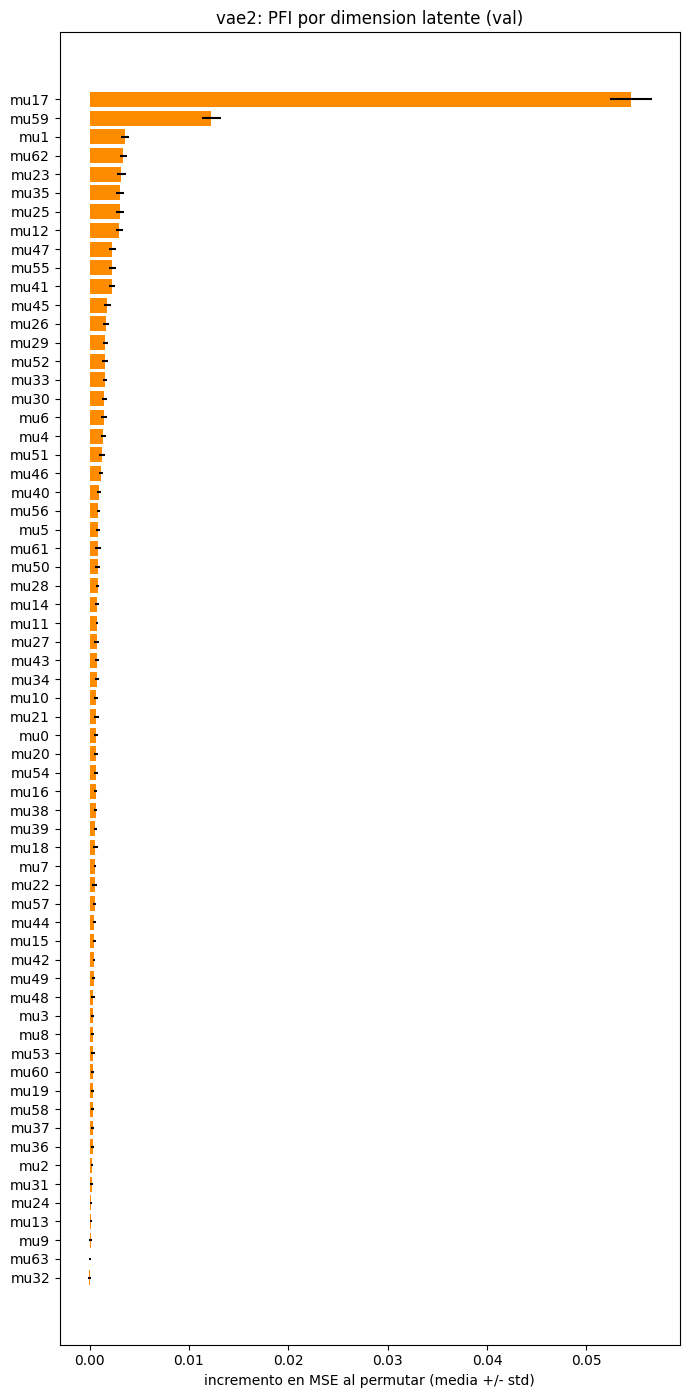

vae2: 63/64 dimensiones latentes seleccionadas (PFI > 0)
--- vae2 - XGB opt + PFI (val) ---
MAE:       0.16484
MSE:       0.05770
RMSE:      0.24021
R2:        0.62560
bias(dz):  0.01763
std(dz):   0.15597
sigma_MAD: 0.10289
eta [%]:   63.581


vae2: comparacion en validacion


,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
Dummy (media),0.338813,0.154114,0.392573,-0.000020,0.059450,0.244977,0.322115,92.199248
XGB default,0.169128,0.060248,0.245455,0.609059,0.018081,0.159215,0.109809,64.943609
XGB optimizado,0.165514,0.058214,0.241275,0.622260,0.018781,0.157423,0.104861,63.674812
XGB opt + PFI,0.164839,0.057700,0.240207,0.625597,0.017632,0.155972,0.102889,63.580827


vae2: mejor modelo en val por eta -> XGB opt + PFI
--- vae2 - XGB opt + PFI (TEST) ---
MAE:       0.17494
MSE:       0.06615
RMSE:      0.25719
R2:        0.56383
bias(dz):  0.02635
std(dz):   0.17062
sigma_MAD: 0.11005
eta [%]:   63.410



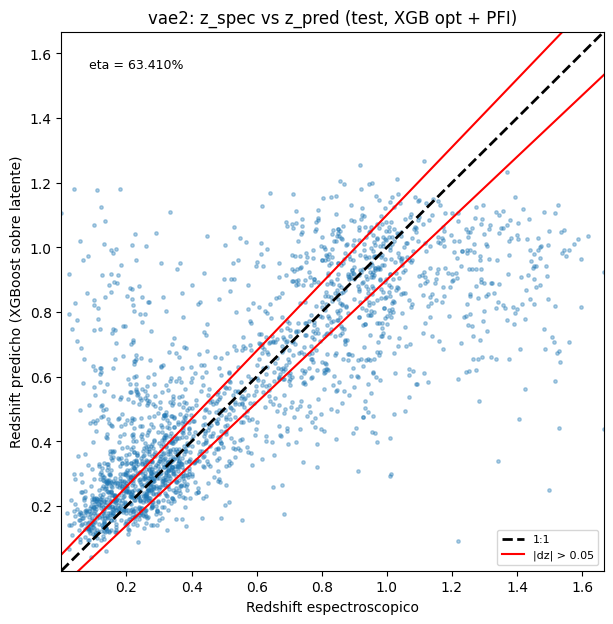

Modelo: vae3
--- vae3 - Dummy (val) ---
MAE:       0.33881
MSE:       0.15411
RMSE:      0.39257
R2:        -0.00002
bias(dz):  0.05945
std(dz):   0.24498
sigma_MAD: 0.32212
eta [%]:   92.199

--- vae3 - XGB default (val) ---
MAE:       0.17928
MSE:       0.06579
RMSE:      0.25649
R2:        0.57313
bias(dz):  0.02171
std(dz):   0.16672
sigma_MAD: 0.11629
eta [%]:   65.602

vae3: mejor MSE (CV) = 0.069056
--- vae3 - XGB optimizado (val) ---
MAE:       0.18088
MSE:       0.06655
RMSE:      0.25798
R2:        0.56815
bias(dz):  0.02240
std(dz):   0.16777
sigma_MAD: 0.11732
eta [%]:   66.823



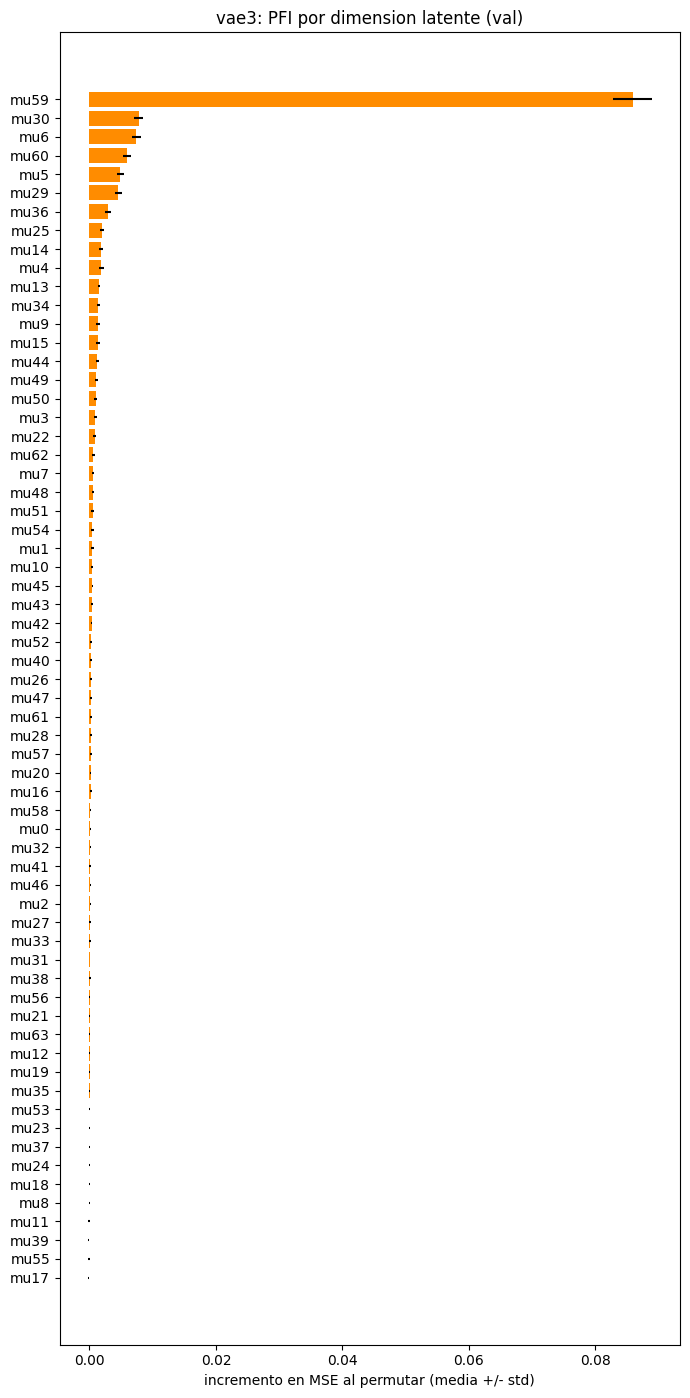

vae3: 54/64 dimensiones latentes seleccionadas (PFI > 0)
--- vae3 - XGB opt + PFI (val) ---
MAE:       0.17982
MSE:       0.06616
RMSE:      0.25721
R2:        0.57073
bias(dz):  0.02188
std(dz):   0.16652
sigma_MAD: 0.11693
eta [%]:   65.883


vae3: comparacion en validacion


,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
Dummy (media),0.338813,0.154114,0.392573,-0.000020,0.059450,0.244977,0.322115,92.199248
XGB default,0.179278,0.065785,0.256486,0.573131,0.021712,0.166721,0.116293,65.601504
XGB optimizado,0.180880,0.066553,0.257979,0.568147,0.022404,0.167767,0.117322,66.823308
XGB opt + PFI,0.179820,0.066155,0.257207,0.570728,0.021877,0.166516,0.116935,65.883459


vae3: mejor modelo en val por eta -> XGB default
--- vae3 - XGB default (TEST) ---
MAE:       0.18641
MSE:       0.06999
RMSE:      0.26456
R2:        0.53846
bias(dz):  0.02711
std(dz):   0.17492
sigma_MAD: 0.12241
eta [%]:   67.309



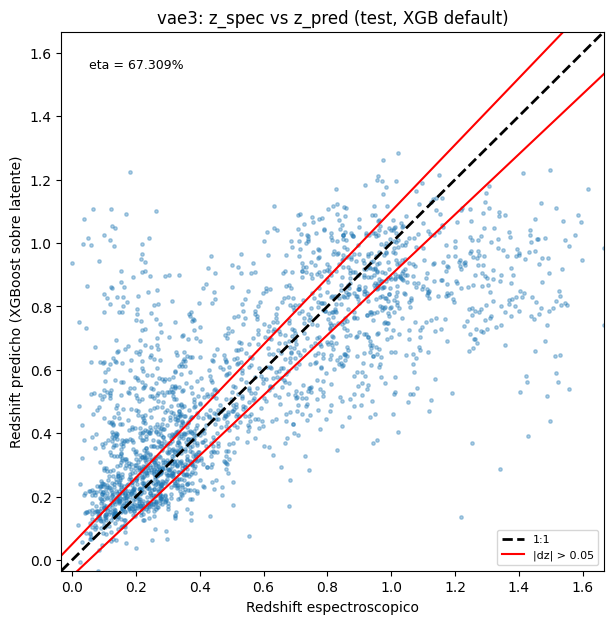

Modelo: vae7
--- vae7 - Dummy (val) ---
MAE:       0.33881
MSE:       0.15411
RMSE:      0.39257
R2:        -0.00002
bias(dz):  0.05945
std(dz):   0.24498
sigma_MAD: 0.32212
eta [%]:   92.199

--- vae7 - XGB default (val) ---
MAE:       0.15963
MSE:       0.05604
RMSE:      0.23673
R2:        0.63635
bias(dz):  0.01570
std(dz):   0.15441
sigma_MAD: 0.10008
eta [%]:   60.855

vae7: mejor MSE (CV) = 0.059531
--- vae7 - XGB optimizado (val) ---
MAE:       0.15944
MSE:       0.05716
RMSE:      0.23908
R2:        0.62910
bias(dz):  0.01647
std(dz):   0.15598
sigma_MAD: 0.09770
eta [%]:   60.291



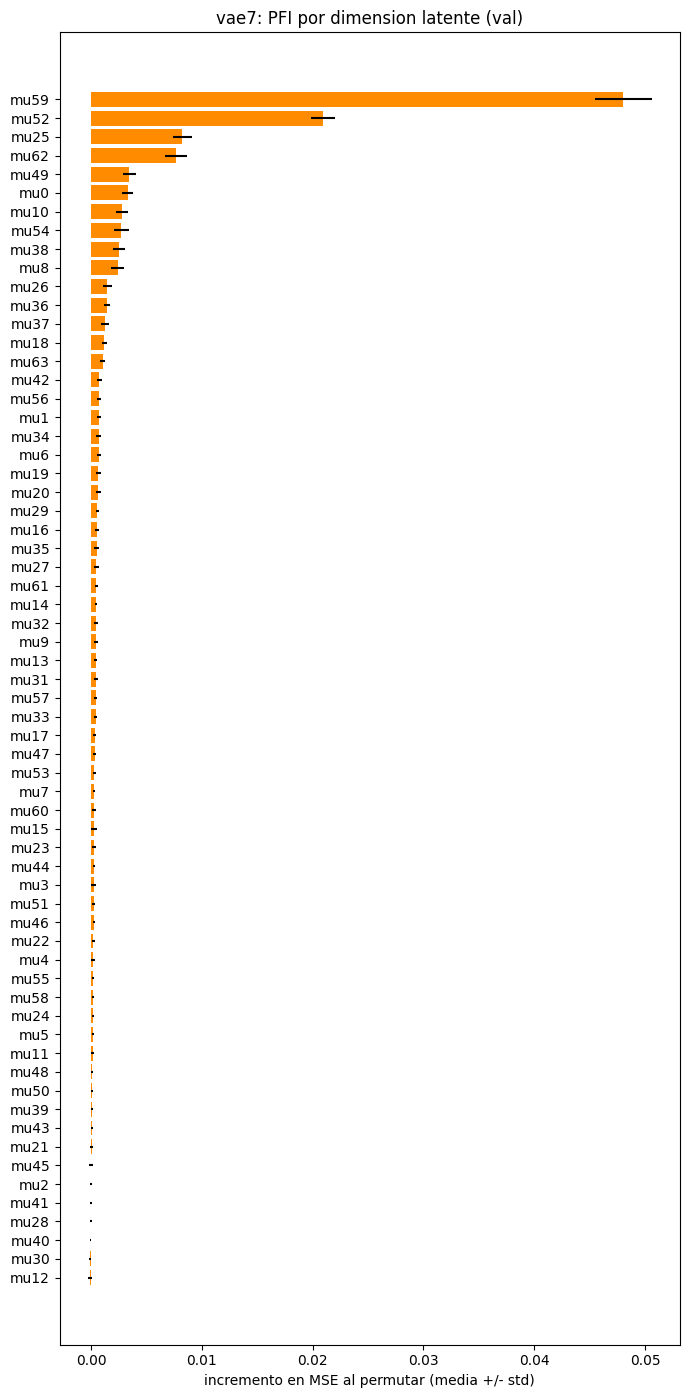

vae7: 60/64 dimensiones latentes seleccionadas (PFI > 0)
--- vae7 - XGB opt + PFI (val) ---
MAE:       0.15794
MSE:       0.05633
RMSE:      0.23734
R2:        0.63449
bias(dz):  0.01584
std(dz):   0.15431
sigma_MAD: 0.09758
eta [%]:   59.258


vae7: comparacion en validacion


,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
Dummy (media),0.338813,0.154114,0.392573,-0.000020,0.059450,0.244977,0.322115,92.199248
XGB default,0.159629,0.056042,0.236733,0.636350,0.015700,0.154407,0.100081,60.855263
XGB optimizado,0.159436,0.057159,0.239080,0.629101,0.016474,0.155978,0.097696,60.291353
XGB opt + PFI,0.157935,0.056328,0.237336,0.634495,0.015839,0.154307,0.097581,59.257519


vae7: mejor modelo en val por eta -> XGB opt + PFI
--- vae7 - XGB opt + PFI (TEST) ---
MAE:       0.17000
MSE:       0.06185
RMSE:      0.24869
R2:        0.59218
bias(dz):  0.02549
std(dz):   0.16373
sigma_MAD: 0.10641
eta [%]:   62.377



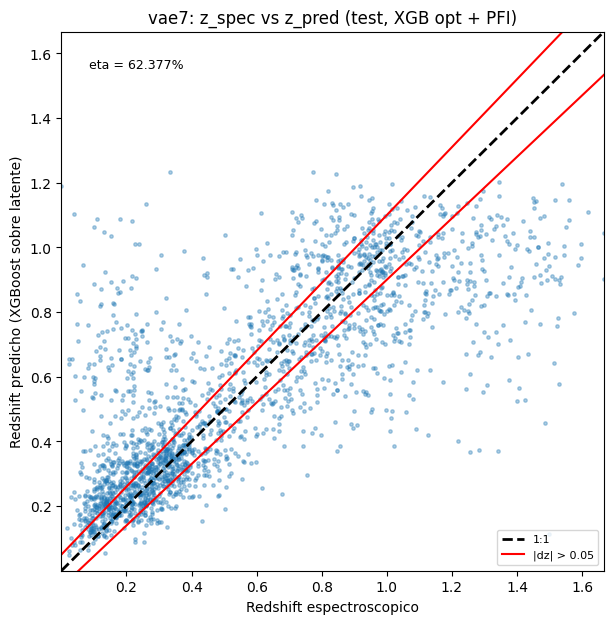

In [18]:
xgb_results = {}
for name, d in latents.items():
    print("=" * 80)
    print(f"Modelo: {name}")
    print("=" * 80)
    xgb_results[name] = run_xgboost_on_latent(
        d["mu"], z_all, idx_train, idx_val, idx_test, name, n_trials=40,
    )


## 6. Comparacion final en test: vae2 vs vae3 vs vae7

Foco en `eta`: la fraccion de objetos con error catastrofico de redshift
(|dz| > 0.05), evaluada **solo** sobre el conjunto de test.

In [19]:
final_comparison = pd.DataFrame({name: r["test_metrics"] for name, r in xgb_results.items()}).T
final_comparison


,MAE,MSE,RMSE,R2,bias,std_dz,sigma_MAD,eta
vae2,0.174940,0.066146,0.257189,0.563827,0.026353,0.170622,0.110050,63.410052
vae3,0.186408,0.069993,0.264562,0.538459,0.027106,0.174920,0.122409,67.308596
vae7,0.169995,0.061847,0.248690,0.592178,0.025489,0.163730,0.106414,62.376703


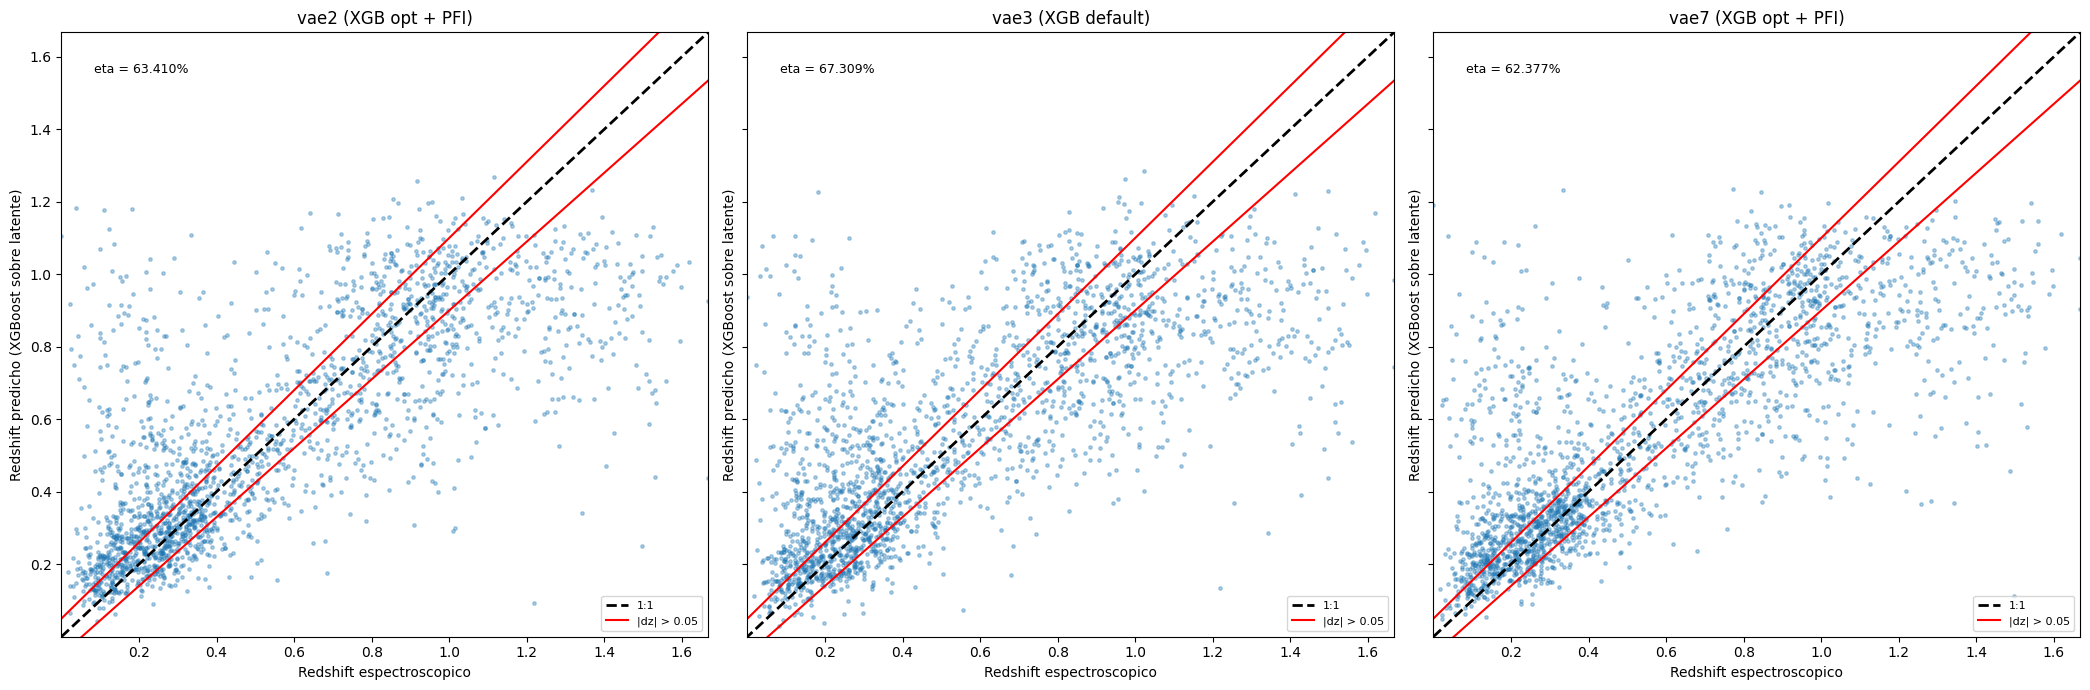

Resumen eta [%] en test:
  vae2: eta = 63.410%  (modelo elegido: XGB opt + PFI)
  vae3: eta = 67.309%  (modelo elegido: XGB default)
  vae7: eta = 62.377%  (modelo elegido: XGB opt + PFI)


In [20]:
fig, axes = plt.subplots(1, len(xgb_results), figsize=(7 * len(xgb_results), 7),
                          sharex=True, sharey=True)
for ax, (name, r) in zip(np.atleast_1d(axes), xgb_results.items()):
    plot_specz_vs_photoz(r["y_test"], r["y_pred_test"],
                          title=f"{name} ({r['best_model_name']})", ax=ax)
plt.tight_layout()
plt.show()

print("Resumen eta [%] en test:")
for name, r in xgb_results.items():
    print(f"  {name}: eta = {r['test_metrics']['eta']:.3f}%  (modelo elegido: {r['best_model_name']})")


## Notas

- El latente usado es `mu` (media de q(z|x)), no una muestra: es la
  representacion determinista que el encoder produce en modo `eval`.
- vae2 y vae3 son VAEs **no supervisados** (`scripts/VAE.py`): el redshift no
  participa en su entrenamiento, por lo que toda la senal que XGBoost logre
  extraer de `mu` es estructura que el VAE aprendio a codificar de forma no
  supervisada y que resulta correlacionada con z (ver seccion 4.4).
- El conjunto de test se evalua una unica vez por modelo, con el regresor ya
  elegido en validacion (seccion 5.1) — evita optimismo por fuga de
  informacion del test hacia la seleccion de hiperparametros o de features.
